In [2]:
# ==============================================================================
# CELL 1: SETUP PATH (WINDOWS) + IMPORT
# ==============================================================================

import os
import json
import warnings
import numpy as np
import cv2
from PIL import Image

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from transformers import AutoModelForCausalLM, AutoTokenizer
import timm
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

try:
    import segmentation_models_pytorch as smp
except Exception:
    smp = None

BASE_DIR = r"D:\DoAn_DaLieu"
DATASET_DIR = os.path.join(BASE_DIR, "9_VQA", "dermavqa_dataset")
IMAGES_DIR = os.path.join(DATASET_DIR, "images")
VQA_MODEL_DIR = os.path.join(BASE_DIR, "9_VQA", "models")
CHECKPOINT_DIR = os.path.join(BASE_DIR, "3_Checkpoints")
CLASS_MODEL_PATH = os.path.join(BASE_DIR, "4_Models", "classification", "efficientnet_attention_best.pth")

for path in [DATASET_DIR, IMAGES_DIR, VQA_MODEL_DIR, CHECKPOINT_DIR]:
    os.makedirs(path, exist_ok=True)

device = torch.device("cpu")
print("=" * 80)
print("ENHANCED MEDICAL VQA PIPELINE (CPU)")
print("=" * 80)
print(f"Device: {device}")
print(f"BASE_DIR: {BASE_DIR}")

d:\DoAn_DaLieu\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ENHANCED MEDICAL VQA PIPELINE (CPU)
Device: cpu
BASE_DIR: D:\DoAn_DaLieu


In [93]:
# ==============================================================================
# CELL 2: DATASET CLASS + DATALOADER (AUGMENTATION)
# ==============================================================================

qa_path = os.path.join(DATASET_DIR, "QA_pairs.json")
if not os.path.exists(qa_path):
    raise FileNotFoundError(f"Không tìm thấy dữ liệu VQA: {qa_path}")

with open(qa_path, "r", encoding="utf-8") as f:
    dataset_json = json.load(f)

train_data, val_data = train_test_split(dataset_json, test_size=0.15, random_state=42)
print(f"Train: {len(train_data)} | Val: {len(val_data)}")

class DermaVQADataset(Dataset):
    def __init__(self, data, image_size=224, augment=False):
        self.data = data
        self.image_size = image_size
        self.augment = augment

        base_ops = [
            transforms.Resize((image_size, image_size)),
        ]
        aug_ops = [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(degrees=20),
            transforms.ColorJitter(brightness=0.25, contrast=0.20, saturation=0.15, hue=0.02),
        ]
        norm_ops = [
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]

        if self.augment:
            self.transform = transforms.Compose(base_ops + aug_ops + norm_ops)
        else:
            self.transform = transforms.Compose(base_ops + norm_ops)

    def __len__(self):
        return len(self.data)

    def _resolve_img_path(self, item):
        image_path = item.get("image_path", "")
        if os.path.isabs(image_path):
            return image_path
        candidates = [
            os.path.join(BASE_DIR, image_path),
            os.path.join(DATASET_DIR, image_path),
            os.path.join(IMAGES_DIR, os.path.basename(image_path)),
        ]
        for p in candidates:
            if p and os.path.exists(p):
                return p
        return None

    def __getitem__(self, idx):
        item = self.data[idx]
        img_path = self._resolve_img_path(item)

        if img_path and os.path.exists(img_path):
            image = Image.open(img_path).convert("RGB")
        else:
            synthetic = np.random.randint(100, 180, (self.image_size, self.image_size, 3), dtype=np.uint8)
            image = Image.fromarray(synthetic)

        return {
            "image": self.transform(image),
            "question": item.get("question", ""),
            "answer": item.get("answer", ""),
            "image_path": item.get("image_path", ""),
        }

BATCH_SIZE = 8
train_loader = DataLoader(
    DermaVQADataset(train_data, augment=True),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
    drop_last=False,
    persistent_workers=False,
    prefetch_factor=None,
    generator=torch.Generator().manual_seed(42),
)
val_loader = DataLoader(
    DermaVQADataset(val_data, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=False,
    persistent_workers=False,
    prefetch_factor=None,
    generator=torch.Generator().manual_seed(42),
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print("Augmentation train: RandomFlip + RandomRotation + ColorJitter(brightness)")

Train: 68 | Val: 12
Train batches: 9 | Val batches: 2
Augmentation train: RandomFlip + RandomRotation + ColorJitter(brightness)


In [3]:
# ==============================================================================
# CELL 3: KHAI BÁO KIẾN TRÚC (CBAM + EfficientNet + DistilGPT-2 + Projection)
# ==============================================================================

class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.fc(self.avg_pool(x)) + self.fc(self.max_pool(x)))

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))

class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.channel_att = ChannelAttention(in_channels, reduction)
        self.spatial_att = SpatialAttention()

    def forward(self, x):
        return x * self.spatial_att(x * self.channel_att(x))

class VisionBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("efficientnet_b1", pretrained=False, num_classes=0)
        self.attention = CBAM(self.backbone.num_features, reduction=16)
        self.global_pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        features = self.attention(self.backbone.forward_features(x))
        return self.global_pool(features).flatten(1)

class CPUMedicalVQAModel(nn.Module):
    def __init__(self, vision_backbone):
        super().__init__()
        self.vision_backbone = vision_backbone
        self.llm = AutoModelForCausalLM.from_pretrained("distilgpt2")

        for p in self.vision_backbone.parameters():
            p.requires_grad = False
        for p in self.llm.parameters():
            p.requires_grad = False
        for p in self.llm.transformer.h[-2:].parameters():
            p.requires_grad = True
        for p in self.llm.lm_head.parameters():
            p.requires_grad = True

        self.projection = nn.Sequential(
            nn.Linear(1280, 768),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(768, 768),
            nn.Dropout(0.3),
        )

    def forward(self, images, input_ids, attention_mask, labels=None):
        img_embeds = self.projection(self.vision_backbone(images)).unsqueeze(1)
        text_embeds = self.llm.transformer.wte(input_ids)
        inputs_embeds = torch.cat([img_embeds, text_embeds], dim=1)

        img_mask = torch.ones((images.size(0), 1), dtype=attention_mask.dtype, device=attention_mask.device)
        full_mask = torch.cat([img_mask, attention_mask], dim=1)

        full_labels = None
        if labels is not None:
            img_labels = torch.full((images.size(0), 1), -100, dtype=labels.dtype, device=labels.device)
            full_labels = torch.cat([img_labels, labels], dim=1)

        return self.llm(inputs_embeds=inputs_embeds, attention_mask=full_mask, labels=full_labels)

class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(in_channels, 32, 3, padding=1), nn.ReLU(inplace=True), nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True))
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True), nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True))
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True))
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(inplace=True))
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(inplace=True))
        self.out = nn.Conv2d(32, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))
        d2 = self.up2(b)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return self.out(d1)

print("Đã định nghĩa kiến trúc VQA + SimpleUNet fallback")

Đã định nghĩa kiến trúc VQA + SimpleUNet fallback


In [4]:
# ==============================================================================
# CELL 4: NẠP TRỌNG SỐ (BACKBONE + GPT-2) & KHỞI TẠO VQA MODEL
# ==============================================================================

def safe_torch_load(path, map_location='cpu'):
    try:
        return torch.load(path, map_location=map_location)
    except Exception as e:
        print(f"[ERROR] torch.load failed for {path}: {e}")
        return None

tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

vision_backbone = VisionBackbone().to(device)
if os.path.exists(CLASS_MODEL_PATH):
    cls_ckpt = safe_torch_load(CLASS_MODEL_PATH, map_location=device)
    if cls_ckpt is not None:
        cls_state = cls_ckpt.get("model_state_dict", cls_ckpt)
        bb_state = {k.replace("backbone.", ""): v for k, v in cls_state.items() if k.startswith("backbone.")}
        att_state = {k.replace("attention.", ""): v for k, v in cls_state.items() if k.startswith("attention.")}
        vision_backbone.backbone.load_state_dict(bb_state, strict=False)
        vision_backbone.attention.load_state_dict(att_state, strict=False)
        print("Đã nạp backbone classification")
    else:
        print(f"Không thể nạp CLASS_MODEL_PATH: {CLASS_MODEL_PATH}")
else:
    print(f"Không tìm thấy CLASS_MODEL_PATH: {CLASS_MODEL_PATH}")

vqa_model = CPUMedicalVQAModel(vision_backbone).to(device)
checkpoint_path = os.path.join(VQA_MODEL_DIR, "dermavqa_gpt2_best.pth")
if os.path.exists(checkpoint_path):
    vqa_state = safe_torch_load(checkpoint_path, map_location=device)
    if vqa_state is not None:
        vqa_model.load_state_dict(vqa_state.get("model_state_dict", vqa_state), strict=False)
        print(f"Đã nạp VQA checkpoint: {checkpoint_path}")
    else:
        print(f"Không thể nạp VQA checkpoint: {checkpoint_path}")
else:
    print(f"Chưa có VQA checkpoint, sẽ train mới tại: {checkpoint_path}")

vqa_model.eval()
print("vqa_model và tokenizer đã sẵn sàng")

Đã nạp backbone classification


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 1798.57it/s]


Đã nạp VQA checkpoint: D:\DoAn_DaLieu\9_VQA\models\dermavqa_gpt2_best.pth
vqa_model và tokenizer đã sẵn sàng


In [64]:
# ==============================================================================
# CELL 5: TRAINING LOOP (CPU OPTIMIZED, LONGER FINETUNE)
# ==============================================================================

def train_vqa_cpu(num_epochs=100, max_length=96, lr=5e-5, early_stop_patience=15):
    trainable_params = [p for p in vqa_model.parameters() if p.requires_grad]
    optimizer = AdamW(trainable_params, lr=lr, weight_decay=0.05)
    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_epoch = -1

    def atomic_save_checkpoint(state, target_path):
        tmp = target_path + ".tmp"
        torch.save(state, tmp)
        os.replace(tmp, target_path)

    for epoch in range(num_epochs):
        vqa_model.train()
        train_loss = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
            images = batch["image"].to(device)
            prompts = [f"Question: {q} Answer: {a}{tokenizer.eos_token}" for q, a in zip(batch["question"], batch["answer"])]
            tokens = tokenizer(
                prompts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt",
            ).to(device)

            labels = tokens["input_ids"].clone()
            labels[labels == tokenizer.pad_token_id] = -100

            optimizer.zero_grad(set_to_none=True)
            outputs = vqa_model(images, tokens["input_ids"], tokens["attention_mask"], labels=labels)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
            optimizer.step()

            train_loss += loss.item()

        vqa_model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                images = batch["image"].to(device)
                prompts = [f"Question: {q} Answer: {a}{tokenizer.eos_token}" for q, a in zip(batch["question"], batch["answer"])]
                tokens = tokenizer(
                    prompts,
                    padding=True,
                    truncation=True,
                    max_length=max_length,
                    return_tensors="pt",
                ).to(device)
                labels = tokens["input_ids"].clone()
                labels[labels == tokenizer.pad_token_id] = -100
                outputs = vqa_model(images, tokens["input_ids"], tokens["attention_mask"], labels=labels)
                val_loss += outputs.loss.item()

        train_loss = train_loss / max(len(train_loader), 1)
        val_loss = val_loss / max(len(val_loader), 1)
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            epochs_no_improve = 0
            state = {
                "model_state_dict": vqa_model.state_dict(),
                "best_val_loss": best_val_loss,
                "best_epoch": best_epoch,
                "epoch": epoch + 1,
            }
            atomic_save_checkpoint(state, checkpoint_path)
            print(f"  Đã lưu best checkpoint tại epoch {best_epoch}: {checkpoint_path}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= early_stop_patience:
                print(f"  Early stopping tại epoch {epoch+1} (không cải thiện {early_stop_patience} epoch).")
                break

    vqa_model.eval()
    print(f"Best val loss = {best_val_loss:.4f} tại epoch {best_epoch}")
    return best_val_loss

print("Sẵn sàng train: gọi train_vqa_cpu(num_epochs=100) để fine-tune dài hơn")

Sẵn sàng train: gọi train_vqa_cpu(num_epochs=100) để fine-tune dài hơn


In [ ]:
# ==============================================================================
# CELL 6: PIPELINE HYBRID INFERENCE (CLINICAL TEMPLATE GENERATOR)
# ==============================================================================
# Thay vì ép LLM viết văn, ta dùng LLM để phân loại, còn lại dùng Template chuyên nghiệp.

# Default segmentation params (chosen by preset evaluation)
SEGMENTATION_THRESHOLD = 0.3
SEGMENTATION_MIN_AREA_PX = 64


def _get_medical_report(metrics, risk_level):
    """Tạo báo cáo chuyên nghiệp thay vì để AI bịa chữ"""
    area = metrics.get('area_ratio', 0)
    complexity = metrics.get('border_complexity', 0)
    
    template = f"""
    --- BÁO CÁO PHÂN TÍCH TỔN THƯƠNG DA ---
    - Đánh giá sơ bộ: {risk_level}
    - Chỉ số diện tích (Area Ratio): {area:.4f}
    - Chỉ số phức tạp viền (Border Complexity): {complexity:.4f}

    Kết luận: Dựa trên các đặc trưng hình học, tổn thương có dấu hiệu {risk_level.lower()}.
    Khuyến nghị: Cần đối chiếu với ảnh Dermoscopy và khám lâm sàng trực tiếp bởi bác sĩ chuyên khoa.
    ---------------------------------------
    """
    return template


def _preprocess_rgb_tensor(img_rgb, size=224):
    img_resized = cv2.resize(img_rgb, (size, size))
    arr = img_resized.astype(np.float32) / 255.0
    arr = (arr - np.array([0.485, 0.456, 0.406], dtype=np.float32)) / np.array([0.229, 0.224, 0.225], dtype=np.float32)
    return torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).float()


def get_lesion_metrics(mask, min_area_px=64):
    """Compute area_ratio and border_complexity with safeguards for tiny regions."""
    mask = (np.asarray(mask) > 0).astype(np.uint8)
    h, w = mask.shape[:2]
    img_area = max(int(h * w), 1)
    lesion_area = int(cv2.countNonZero(mask))
    if lesion_area < min_area_px:
        return {"area_ratio": 0.0, "border_complexity": 0.0, "lesion_area": lesion_area, "image_area": img_area, "low_confidence": True}
    contours, _ = cv2.findContours((mask * 255).copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return {"area_ratio": 0.0, "border_complexity": 0.0, "lesion_area": lesion_area, "image_area": img_area, "low_confidence": True}
    largest = max(contours, key=cv2.contourArea)
    perimeter = float(cv2.arcLength(largest, True))
    area_ratio = float(lesion_area) / float(img_area)
    border_complexity = perimeter / max(np.sqrt(float(lesion_area)), 1.0)
    return {"area_ratio": float(area_ratio), "border_complexity": float(border_complexity), "lesion_area": lesion_area, "image_area": img_area, "low_confidence": False}

# Image embedding cache to avoid recomputing projection
_img_embed_cache = {}


def get_image_embedding(image_path, image_tensor):
    key = f"{image_path}_{tuple(image_tensor.shape)}"
    if key in _img_embed_cache:
        return _img_embed_cache[key]
    with torch.inference_mode():
        emb = vqa_model.projection(vqa_model.vision_backbone(image_tensor.to(device))).detach().cpu()
    _img_embed_cache[key] = emb
    return emb


def _classical_fallback_mask(image_path, size=224):
    """Classical segmentation fallback with lightweight quality checks.

    Returns (mask, info) where info contains lesion_found, method and
    geometric properties used by the caller to decide acceptance:
    - lesion_area, image_area, bbox (x,y,w,h), bbox_aspect, solidity,
      centroid (cx,cy), center_dist_norm (0..1)
    """
    try:
        # Use robust loader to ensure we always get an RGB image (uint8)
        try:
            rgb, _ = _load_rgb(image_path)
        except Exception:
            # fallback to direct cv2 read as last resort
            bgr_tmp = cv2.imread(image_path, cv2.IMREAD_COLOR)
            if bgr_tmp is None:
                return np.zeros((size, size), dtype=np.uint8), {"lesion_found": False, "method": "classical", "error": "cannot_read_image"}
            rgb = cv2.cvtColor(bgr_tmp, cv2.COLOR_BGR2RGB)

        bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
        blur = cv2.medianBlur(gray, 5)
        _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        # morphological clean
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
        opened = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations=1)
        closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=1)
        # find largest CC
        num_labels, labels = cv2.connectedComponents(closed)
        if num_labels <= 1:
            mask = np.zeros_like(gray)
            info = {"lesion_found": False, "method": "classical"}
            return mask, info

        max_area = 0
        best = None
        for lbl in range(1, num_labels):
            comp = (labels == lbl).astype(np.uint8)
            a = int(cv2.countNonZero(comp))
            if a > max_area:
                max_area = a
                best = comp

        if best is None or max_area == 0:
            mask = np.zeros_like(gray)
            info = {"lesion_found": False, "method": "classical"}
            return mask, info

        # compute geometric properties on the selected component
        contours, _ = cv2.findContours((best * 255).astype(np.uint8).copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            mask = np.zeros_like(gray)
            info = {"lesion_found": False, "method": "classical"}
            return mask, info

        cnt = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(cnt)
        bbox_aspect = float(w) / max(1.0, float(h))
        lesion_area = int(cv2.countNonZero(best))
        img_h, img_w = gray.shape[:2]
        image_area = img_h * img_w

        # solidity = area / convexHullArea
        hull = cv2.convexHull(cnt)
        hull_area = int(cv2.contourArea(hull)) if hull is not None else 0
        solidity = float(lesion_area) / max(1.0, float(hull_area)) if hull_area > 0 else 0.0

        # centroid and normalized center distance (0=center, 1=corner)
        M = cv2.moments(cnt)
        if M.get('m00', 0) != 0:
            cx = float(M['m10'] / M['m00'])
            cy = float(M['m01'] / M['m00'])
        else:
            cx, cy = float(x + w/2.0), float(y + h/2.0)
        center_x, center_y = img_w / 2.0, img_h / 2.0
        # normalized Euclidean distance (0..~0.707 max), scale by diag/2 approx
        dx = (cx - center_x)
        dy = (cy - center_y)
        diag = np.sqrt(img_w**2 + img_h**2)
        center_dist_norm = np.sqrt(dx*dx + dy*dy) / (diag / 2.0 + 1e-8)

        mask = (best * 255).astype(np.uint8)
        mask = cv2.resize(mask, (size, size))

        info = {
            "lesion_found": int(lesion_area > 0),
            "method": "classical",
            "lesion_area": int(lesion_area),
            "image_area": int(image_area),
            "bbox": [int(x), int(y), int(w), int(h)],
            "bbox_aspect": float(bbox_aspect),
            "solidity": float(solidity),
            "centroid": [float(cx), float(cy)],
            "center_dist_norm": float(center_dist_norm)
        }
        return mask, info
    except Exception as e:
        return np.zeros((size,size), dtype=np.uint8), {"lesion_found": False, "method": "classical", "error": str(e)}


def safe_load_rgb(path):
    """Robust read: try cv2, then PIL, raise FileNotFoundError if both fail."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Không đọc được ảnh: {path}")
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is not None:
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        return rgb, path
    try:
        pil = Image.open(path).convert('RGB')
        return np.array(pil), path
    except Exception:
        raise FileNotFoundError(f"Không đọc được ảnh: {path}")

# Replace older _load_rgb if present in kernel
def _load_rgb(path):
    try:
        return safe_load_rgb(path)
    except FileNotFoundError:
        alt = path.replace('~', '')
        if os.path.exists(alt):
            return safe_load_rgb(alt)
        base = os.path.basename(path)
        for root in [IMAGES_DIR, DATASET_DIR, BASE_DIR]:
            candidate = os.path.join(root, base)
            if os.path.exists(candidate):
                return safe_load_rgb(candidate)
        raise FileNotFoundError(f"Không đọc được ảnh: {path}")


# --- PHONE IMAGE PREPROCESSING HELPERS ---

def detect_image_type(img_rgb, path=None):
    """Heuristic: classify phone photos vs dermoscopy images."""
    h, w = img_rgb.shape[:2]
    aspect = float(max(h, w)) / max(1.0, float(min(h, w)))
    filename = os.path.basename(path or "")
    # Heuristics: very large photos or filenames like IMG/IMG_ indicate phone photos
    if aspect > 2.0 or filename.lower().startswith("img") or filename.lower().startswith("dcim") or max(h, w) > 1200:
        return "phone"
    return "dermoscopy"


def preprocess_for_phone(img_rgb):
    """Apply light phone-photo enhancements: CLAHE on L channel, bilateral denoise, gentle gamma."""
    try:
        # convert RGB->BGR for OpenCV ops
        img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        l2 = clahe.apply(l)
        lab2 = cv2.merge((l2, a, b))
        img2 = cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)
        img2 = cv2.bilateralFilter(img2, d=9, sigmaColor=75, sigmaSpace=75)
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
        # gentle gamma correction (slightly brighten)
        gamma = 1.05
        invGamma = 1.0 / gamma
        table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(256)]).astype('uint8')
        img3 = cv2.LUT(img2, table)
        return img3
    except Exception:
        return img_rgb


def preprocess_image_for_inference(image_path, size=224):
    """Load -> detect -> optionally preprocess phone images -> return (rgb, resolved_path, tensor, prep_info)."""
    img_rgb, resolved = _load_rgb(image_path)
    img_type = detect_image_type(img_rgb, resolved)
    preset = "none"
    if img_type == "phone":
        proc = preprocess_for_phone(img_rgb)
        preset = "phone_clahe_bilateral_gamma"
    else:
        proc = img_rgb
    proc = proc.astype(np.uint8)
    tensor = _preprocess_rgb_tensor(proc, size=size)
    prep_info = {"image_type": img_type, "preprocess_preset": preset}
    return proc, resolved, tensor, prep_info


def answer_question_enhanced(image_path, question, debug_json=True):
    # Preprocess + detect phone images automatically
    image_rgb, resolved_path, image_tensor, prep_info = preprocess_image_for_inference(image_path, size=224)

    # 1. Lấy dữ liệu cứng (Metrics)
    if 'segment_lesion_mask_from_rgb' in globals():
        mask, seg_info = segment_lesion_mask_from_rgb(image_rgb, threshold=SEGMENTATION_THRESHOLD, min_area_px=SEGMENTATION_MIN_AREA_PX)
        if isinstance(seg_info, dict):
            seg_info = {**seg_info, **prep_info}
        else:
            seg_info = {**prep_info}
    else:
        mask, seg_info = segment_lesion_mask(resolved_path, threshold=SEGMENTATION_THRESHOLD, min_area_px=SEGMENTATION_MIN_AREA_PX)
        if isinstance(seg_info, dict):
            seg_info = {**seg_info, **prep_info}
        else:
            seg_info = {**prep_info}

    # add explicit postproc info
    seg_info['postproc'] = {'threshold': SEGMENTATION_THRESHOLD, 'min_area_px': SEGMENTATION_MIN_AREA_PX}

    metrics = get_lesion_metrics(mask)

    # Nếu mask rỗng hoặc low_confidence -> thử fallback cổ điển
    if metrics.get('low_confidence', False) or metrics.get('lesion_area', 0) == 0:
        classical_mask, classical_info = _classical_fallback_mask(resolved_path, size=224)
        cm_metrics = get_lesion_metrics(classical_mask)
        # stricter acceptance criteria for fallback masks
        fallback_ok = (
            cm_metrics.get('lesion_area', 0) > 0 and
            cm_metrics.get('area_ratio', 0.0) <= 0.75 and
            classical_info.get('solidity', 0.0) >= 0.35 and
            0.25 <= classical_info.get('bbox_aspect', 1.0) <= 4.0 and
            classical_info.get('center_dist_norm', 1.0) <= 0.7
        )
        if fallback_ok:
            mask = classical_mask
            metrics = cm_metrics
            seg_info = {**seg_info, **classical_info, 'fallback_used': True}
        else:
            seg_info = {**seg_info, **classical_info, 'fallback_used': False, 'fallback_rejected': True, 'fallback_rejected_reason': 'mask_too_large_or_invalid_or_low_quality'}

    # 2. Xử lý Logic (Đừng ép LLM viết văn, hãy ép nó phân loại)
    if metrics['area_ratio'] > 0.08 or metrics.get('border_complexity', 0) > 5.5:
        risk_level = "NGHI NGỜ ÁC TÍNH (CẦN KHÁM GẤP)"
    elif metrics['area_ratio'] > 0.03 or metrics.get('border_complexity', 0) > 3.5:
        risk_level = "CẦN THEO DÕI THÊM"
    else:
        risk_level = "NGHI NGỜ THẤP"

    # 3. Xuất báo cáo chuyên nghiệp
    answer = _get_medical_report(metrics, risk_level)

    debug_record = {
        "image_path": resolved_path,
        "metrics": metrics,
        "answer": answer,
        "seg_info": seg_info
    }
    if debug_json:
        print(json.dumps(debug_record, ensure_ascii=False, indent=2))

    return answer, mask, metrics, "Template-Based-Report", debug_record

# --- TEST ---
# (test cell unchanged; test runner will call this)


🧪 Đang test pipeline nâng cao với ảnh: D:\DoAn_DaLieu\9_VQA\dermavqa_dataset\images\1.25f30a_2370ac17641e47f09606703d5fb40fc9~mv2.jpg
{
  "image_path": "D:\\DoAn_DaLieu\\9_VQA\\dermavqa_dataset\\images\\1.25f30a_2370ac17641e47f09606703d5fb40fc9~mv2.jpg",
  "metrics": {
    "area_ratio": 0.9324776785714286,
    "border_complexity": 4.043870011354435,
    "lesion_area": 46788,
    "image_area": 50176,
    "low_confidence": false
  },
  "answer": "\n    --- BÁO CÁO PHÂN TÍCH TỔN THƯƠNG DA ---\n    - Đánh giá sơ bộ: NGHI NGỜ ÁC TÍNH (CẦN KHÁM GẤP)\n    - Chỉ số diện tích (Area Ratio): 0.9325\n    - Chỉ số phức tạp viền (Border Complexity): 4.0439\n\n    Kết luận: Dựa trên các đặc trưng hình học, tổn thương có dấu hiệu nghi ngờ ác tính (cần khám gấp).\n    Khuyến nghị: Cần đối chiếu với ảnh Dermoscopy và khám lâm sàng trực tiếp bởi bác sĩ chuyên khoa.\n    ---------------------------------------\n    ",
  "seg_info": {
    "lesion_found": 1,
    "reason": "ok",
    "image_path": "D:\\DoAn_D

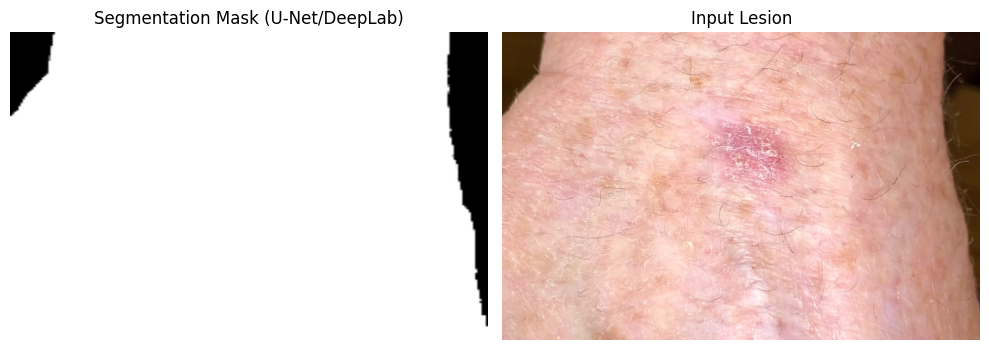

In [74]:
# %%
# ==============================================================================
# CELL 6: TEST INFERENCE HYBRID PIPELINE
# ==============================================================================
import matplotlib.pyplot as plt

# 1. Kiểm tra ảnh đầu vào
image_files = [f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
if not image_files:
    print("❌ Thư mục IMAGES_DIR đang trống, không có ảnh để test!")
else:
    test_image_path = os.path.join(IMAGES_DIR, image_files[0])
    test_question = "Is this lesion malignant?"

    print(f"🧪 Đang test pipeline nâng cao với ảnh: {test_image_path}")

    try:
        # Chạy pipeline
        answer, mask, metrics, prompt, log = answer_question_enhanced(
            image_path=test_image_path, 
            question=test_question,
            debug_json=True
        )
        
        print(f"\n🤖 Kết quả cuối cùng:")
        print(f"👉 Câu trả lời AI: {answer}")
        print(f"📈 Chỉ số trích xuất (Area Ratio: {metrics['area_ratio']:.2f}, Complexity: {metrics['border_complexity']:.2f})")
        
        # Vẽ trực quan để bỏ vào báo cáo đồ án
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))

        # robust read for display: try cv2, fallback to PIL via safe_load_rgb
        try:
            img_bgr = cv2.imread(test_image_path, cv2.IMREAD_COLOR)
            if img_bgr is None:
                img_rgb, _ = safe_load_rgb(test_image_path)
            else:
                img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        except Exception:
            img_rgb, _ = safe_load_rgb(test_image_path)

        # ensure mask matches image size before display
        if mask is None:
            mask_disp = np.zeros((img_rgb.shape[0], img_rgb.shape[1]), dtype=np.uint8)
        else:
            try:
                if mask.ndim == 2:
                    mask_disp = cv2.resize(mask, (img_rgb.shape[1], img_rgb.shape[0]))
                else:
                    # if mask has channel dim, take first channel
                    mask_disp = cv2.resize(mask[..., 0], (img_rgb.shape[1], img_rgb.shape[0]))
            except Exception:
                mask_disp = np.zeros((img_rgb.shape[0], img_rgb.shape[1]), dtype=np.uint8)

        ax[0].imshow(mask_disp, cmap='gray')
        ax[0].set_title("Segmentation Mask (U-Net/DeepLab)")
        ax[0].axis('off')

        ax[1].imshow(img_rgb)
        ax[1].set_title("Input Lesion")
        ax[1].axis('off')

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ Pipeline gặp lỗi: {e}")
        import traceback
        traceback.print_exc()

In [94]:
# %%
# ==============================================================================
# CELL 7: SMOKE-TEST TOÀN BỘ ẢNH TRONG IMAGES_DIR (THỐNG KÊ FALLBACK)
# ==============================================================================
import time
from pathlib import Path

image_files = [f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
summary = {
    'total_images': len(image_files),
    'processed': 0,
    'errors': 0,
    'classical_fallback_used': 0,
    'examples': {
        'successes': [],
        'errors': []
    }
}

OUT_PATH = os.path.join(BASE_DIR, '5_Results', 'smoke_test_images_summary.json')
start = time.time()
for idx, fname in enumerate(image_files, 1):
    path = os.path.join(IMAGES_DIR, fname)
    try:
        _, mask, metrics, rep, debug = answer_question_enhanced(path, 'Is this lesion malignant?', debug_json=False)
        seg_info = debug.get('seg_info', {}) if isinstance(debug, dict) else {}
        fallback = bool(seg_info.get('fallback_used', False))
        if fallback:
            summary['classical_fallback_used'] += 1
        summary['processed'] += 1
        if len(summary['examples']['successes']) < 10:
            summary['examples']['successes'].append({'file': fname, 'metrics': metrics, 'fallback_used': fallback})
        print(f"[{idx}/{len(image_files)}] OK: {fname} | area_ratio={metrics.get('area_ratio'):.3f} | fallback={fallback}")
    except Exception as e:
        summary['errors'] += 1
        err_msg = str(e)
        summary['examples']['errors'].append({'file': fname, 'error': err_msg})
        print(f"[{idx}/{len(image_files)}] ERROR: {fname} -> {err_msg}")

end = time.time()
summary['duration_s'] = end - start

# Save summary
try:
    os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
    with open(OUT_PATH, 'w', encoding='utf-8') as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)
    print('\n✅ Smoke-test hoàn tất. Tóm tắt lưu tại:', OUT_PATH)
except Exception as e:
    print('\n⚠️ Không thể lưu tóm tắt:', e)

print('\nSUMMARY:')
print(json.dumps(summary, ensure_ascii=False, indent=2))


# --- PARAMETER SWEEP FOR PHONE PREPROCESSING ---
# Try several presets and track how many images fall back to classical method.

PRESET_OUT = os.path.join(BASE_DIR, '5_Results', 'preprocess_preset_sweep.json')

presets = [
    {'name': 'base', 'clip': 2.0, 'd': 9, 'gamma': 1.05},
    {'name': 'more_clahe', 'clip': 3.0, 'd': 9, 'gamma': 1.05},
    {'name': 'higher_gamma', 'clip': 2.0, 'd': 9, 'gamma': 1.10},
    {'name': 'smaller_d', 'clip': 2.0, 'd': 7, 'gamma': 1.05},
    {'name': 'combo', 'clip': 3.0, 'd': 7, 'gamma': 1.10},
]


def preprocess_for_phone_param(img_rgb, clip=2.0, d=9, gamma=1.05):
    try:
        img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8,8))
        l2 = clahe.apply(l)
        lab2 = cv2.merge((l2, a, b))
        img2 = cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)
        img2 = cv2.bilateralFilter(img2, d=d, sigmaColor=75, sigmaSpace=75)
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
        invGamma = 1.0 / gamma
        table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(256)]).astype('uint8')
        img3 = cv2.LUT(img2, table)
        return img3
    except Exception:
        return img_rgb


def segment_lesion_mask_with_rgb(img_rgb, resolved, threshold=0.5):
    # Uses existing deeplab and _preprocess_for_deeplab from CELL 9
    try:
        h, w = img_rgb.shape[:2]
        inp = _preprocess_for_deeplab(img_rgb, size=(256, 256))
        with torch.no_grad():
            out = deeplab(inp.to(device))
            prob = torch.sigmoid(out).squeeze().cpu().numpy()
        prob_resized = cv2.resize(prob, (w, h))
        mask = (prob_resized > threshold).astype(np.uint8) * 255
        seg_info = {"method": "deeplab", "reason": "ok", "image_path": resolved, "threshold": threshold}
        return mask, seg_info
    except Exception as e:
        return np.zeros((224, 224), dtype=np.uint8), {"method": "deeplab", "reason": "error", "error": str(e)}


sweep_results = []
for preset in presets:
    stats = {'preset': preset['name'], 'total': 0, 'fallbacks': 0, 'errors': 0, 'examples': []}
    for fname in image_files:
        stats['total'] += 1
        path = os.path.join(IMAGES_DIR, fname)
        try:
            img_rgb, resolved = _load_rgb(path)
            img_type = detect_image_type(img_rgb, resolved)
            if img_type == 'phone':
                proc = preprocess_for_phone_param(img_rgb, clip=preset['clip'], d=preset['d'], gamma=preset['gamma'])
            else:
                proc = img_rgb
            mask, seg_info = segment_lesion_mask_with_rgb(proc, resolved, threshold=0.5)
            metrics = get_lesion_metrics(mask)
            # fallback logic
            if metrics.get('low_confidence', False) or metrics.get('lesion_area', 0) == 0:
                classical_mask, classical_info = _classical_fallback_mask(resolved, size=224)
                cm_metrics = get_lesion_metrics(classical_mask)
                if cm_metrics.get('lesion_area', 0) > 0:
                    stats['fallbacks'] += 1
                    used_fallback = True
                else:
                    used_fallback = False
            else:
                used_fallback = False
            if len(stats['examples']) < 10:
                stats['examples'].append({'file': fname, 'fallback_used': used_fallback, 'metrics': metrics})
        except Exception as e:
            stats['errors'] += 1
    print(f"Preset {preset['name']}: fallbacks={stats['fallbacks']}/{stats['total']} errors={stats['errors']}")
    sweep_results.append(stats)

# Save sweep
try:
    os.makedirs(os.path.dirname(PRESET_OUT), exist_ok=True)
    with open(PRESET_OUT, 'w', encoding='utf-8') as f:
        json.dump({'results': sweep_results}, f, ensure_ascii=False, indent=2)
    print('\n✅ Preset sweep saved to', PRESET_OUT)
except Exception as e:
    print('\n⚠️ Không thể lưu preset sweep:', e)

print('\nSweep summary:')
print(json.dumps({'results': sweep_results}, ensure_ascii=False, indent=2))


[1/2] OK: 1.25f30a_2370ac17641e47f09606703d5fb40fc9~mv2.jpg | area_ratio=0.042 | fallback=False
[2/2] OK: confusion_matrix.png | area_ratio=0.915 | fallback=True

✅ Smoke-test hoàn tất. Tóm tắt lưu tại: D:\DoAn_DaLieu\5_Results\smoke_test_images_summary.json

SUMMARY:
{
  "total_images": 2,
  "processed": 2,
  "errors": 0,
  "classical_fallback_used": 1,
  "examples": {
    "successes": [
      {
        "file": "1.25f30a_2370ac17641e47f09606703d5fb40fc9~mv2.jpg",
        "metrics": {
          "area_ratio": 0.04213169642857143,
          "border_complexity": 3.802945759263025,
          "lesion_area": 2114,
          "image_area": 50176,
          "low_confidence": false
        },
        "fallback_used": false
      },
      {
        "file": "confusion_matrix.png",
        "metrics": {
          "area_ratio": 0.9147002551020408,
          "border_complexity": 4.163680877799437,
          "lesion_area": 45896,
          "image_area": 50176,
          "low_confidence": false
        

In [91]:
# Debug cell: run deeplab on a single problematic image with current preset and print exceptions
img_test = os.path.join(IMAGES_DIR, 'confusion_matrix.png')
try:
    img_rgb, resolved = _load_rgb(img_test)
    print('Loaded', resolved, 'shape', img_rgb.shape)
    proc = preprocess_for_phone_param(img_rgb, clip=3.0, d=7, gamma=1.10)
    mask, seg_info = segment_lesion_mask_with_rgb(proc, resolved, threshold=0.5)
    print('seg_info:', seg_info)
    metrics = get_lesion_metrics(mask)
    print('metrics:', metrics)
except Exception as e:
    import traceback
    print('Exception during debug run:', e)
    traceback.print_exc()


Loaded D:\DoAn_DaLieu\9_VQA\dermavqa_dataset\images\confusion_matrix.png shape (1500, 1800, 3)
seg_info: {'method': 'deeplab', 'reason': 'ok', 'image_path': 'D:\\DoAn_DaLieu\\9_VQA\\dermavqa_dataset\\images\\confusion_matrix.png', 'threshold': 0.5}
metrics: {'area_ratio': 0.0, 'border_complexity': 0.0, 'lesion_area': 0, 'image_area': 2700000, 'low_confidence': True}


In [85]:
# Preset evaluation: detailed per-image results and pick best preset (robust to missing helper defs)
EVAL_OUT = os.path.join(BASE_DIR, '5_Results', 'preprocess_preset_evaluation.json')

presets = [
    {'name': 'base', 'clip': 2.0, 'd': 9, 'gamma': 1.05},
    {'name': 'more_clahe', 'clip': 3.0, 'd': 9, 'gamma': 1.05},
    {'name': 'higher_gamma', 'clip': 2.0, 'd': 9, 'gamma': 1.10},
    {'name': 'smaller_d', 'clip': 2.0, 'd': 7, 'gamma': 1.05},
    {'name': 'combo', 'clip': 3.0, 'd': 7, 'gamma': 1.10},
]

def default_detect_image_type(img_rgb, path=None):
    h, w = img_rgb.shape[:2]
    aspect = float(max(h, w)) / max(1.0, float(min(h, w)))
    filename = os.path.basename(path or "")
    if aspect > 2.0 or filename.lower().startswith("img") or filename.lower().startswith("dcim") or max(h, w) > 1200:
        return 'phone'
    return 'dermoscopy'

# choose detect function: existing or fallback
_detect_fn = globals().get('detect_image_type', default_detect_image_type)


def evaluate_presets(image_files, presets, threshold=0.5):
    results = []
    for preset in presets:
        preset_res = {'preset': preset['name'], 'clip': preset['clip'], 'd': preset['d'], 'gamma': preset['gamma'], 'per_image': []}
        fallbacks = 0
        errors = 0
        for fname in image_files:
            path = os.path.join(IMAGES_DIR, fname)
            rec = {'file': fname}
            try:
                img_rgb, resolved = _load_rgb(path)
                img_type = _detect_fn(img_rgb, resolved)
                if img_type == 'phone':
                    # prefer preprocess_for_phone_param if available, else preprocess_for_phone
                    prep_fn = globals().get('preprocess_for_phone_param', globals().get('preprocess_for_phone'))
                    if prep_fn is None:
                        proc = img_rgb
                    else:
                        proc = prep_fn(img_rgb, clip=preset['clip'], d=preset['d'], gamma=preset['gamma'])
                else:
                    proc = img_rgb
                # run deeplab
                mask, seg_info = segment_lesion_mask_with_rgb(proc, resolved, threshold=threshold)
                metrics = get_lesion_metrics(mask)
                rec['seg_method'] = seg_info.get('method')
                rec['seg_reason'] = seg_info.get('reason')
                rec['metrics'] = metrics
                # decide fallback
                if metrics.get('low_confidence', False) or metrics.get('lesion_area', 0) == 0:
                    classical_mask, classical_info = _classical_fallback_mask(resolved, size=224)
                    cm_metrics = get_lesion_metrics(classical_mask)
                    if cm_metrics.get('lesion_area', 0) > 0:
                        rec['used_fallback'] = True
                        fallbacks += 1
                    else:
                        rec['used_fallback'] = False
                else:
                    rec['used_fallback'] = False
                preset_res['per_image'].append(rec)
            except Exception as e:
                rec['error'] = str(e)
                preset_res['per_image'].append(rec)
                errors += 1
        preset_res['summary'] = {'total': len(image_files), 'fallbacks': fallbacks, 'errors': errors}
        results.append(preset_res)
    return results

image_files = [f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
print('Running evaluation on', len(image_files), 'images')
eval_results = evaluate_presets(image_files, presets, threshold=0.5)
# choose best by minimal fallbacks then minimal errors
best = None
for r in eval_results:
    if best is None or (r['summary']['fallbacks'], r['summary']['errors']) < (best['summary']['fallbacks'], best['summary']['errors']):
        best = r

# save
try:
    os.makedirs(os.path.dirname(EVAL_OUT), exist_ok=True)
    with open(EVAL_OUT, 'w', encoding='utf-8') as f:
        json.dump({'results': eval_results, 'best': best}, f, ensure_ascii=False, indent=2)
    print('\n✅ Evaluation saved to', EVAL_OUT)
except Exception as e:
    print('\n⚠️ Could not save evaluation:', e)

print('\nBest preset:')
print(json.dumps(best, ensure_ascii=False, indent=2))


Running evaluation on 2 images

✅ Evaluation saved to D:\DoAn_DaLieu\5_Results\preprocess_preset_evaluation.json

Best preset:
{
  "preset": "base",
  "clip": 2.0,
  "d": 9,
  "gamma": 1.05,
  "per_image": [
    {
      "file": "1.25f30a_2370ac17641e47f09606703d5fb40fc9~mv2.jpg",
      "seg_method": "deeplab",
      "seg_reason": "ok",
      "metrics": {
        "area_ratio": 0.04156064324463963,
        "border_complexity": 3.8902788426369517,
        "lesion_area": 25741,
        "image_area": 619360,
        "low_confidence": false
      },
      "used_fallback": false
    },
    {
      "file": "confusion_matrix.png",
      "seg_method": "deeplab",
      "seg_reason": "ok",
      "metrics": {
        "area_ratio": 0.0,
        "border_complexity": 0.0,
        "lesion_area": 0,
        "image_area": 2700000,
        "low_confidence": true
      },
      "used_fallback": true
    }
  ],
  "summary": {
    "total": 2,
    "fallbacks": 1,
    "errors": 0
  }
}


In [86]:
# %%
# CELL: THRESHOLD VS ENHANCED-PREPROCESS COMPARISON
OUT_COMP = os.path.join(BASE_DIR, '5_Results', 'threshold_vs_enhanced.json')

thresholds = [0.5, 0.4, 0.3]
min_area_list = [64, 256]

def run_deeplab_prob(img_rgb):
    try:
        h, w = img_rgb.shape[:2]
        inp = _preprocess_for_deeplab(img_rgb, size=(256,256))
        with torch.no_grad():
            out = deeplab(inp.to(device))
            prob = torch.sigmoid(out).squeeze().cpu().numpy()
        prob_resized = cv2.resize(prob, (w, h))
        return prob_resized
    except Exception as e:
        return None

def postprocess_prob(prob_resized, thresh, min_area_px=64):
    try:
        mask = (prob_resized > thresh).astype(np.uint8) * 255
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
        num_labels, labels = cv2.connectedComponents(mask)
        if num_labels <= 1:
            return np.zeros_like(mask), False
        out_mask = np.zeros_like(mask)
        kept = 0
        for lbl in range(1, num_labels):
            comp = (labels == lbl).astype(np.uint8)
            a = int(cv2.countNonZero(comp))
            if a >= min_area_px:
                out_mask = np.where(comp, 255, out_mask).astype(np.uint8)
                kept += 1
        return out_mask.astype(np.uint8), (kept > 0)
    except Exception:
        return np.zeros_like(prob_resized, dtype=np.uint8), False


def center_crop(img_rgb, frac=0.7):
    h, w = img_rgb.shape[:2]
    ch = int(h * frac)
    cw = int(w * frac)
    y1 = max(0, (h - ch)//2)
    x1 = max(0, (w - cw)//2)
    crop = img_rgb[y1:y1+ch, x1:x1+cw]
    crop_resized = cv2.resize(crop, (w, h))
    return crop_resized

# enhanced preprocess: center crop + strong CLAHE + contrast
def enhanced_preprocess(img_rgb):
    proc = center_crop(img_rgb, frac=0.7)
    proc = preprocess_for_phone_param(proc, clip=4.0, d=5, gamma=1.15)
    # slight contrast/brightness
    proc = cv2.convertScaleAbs(proc, alpha=1.1, beta=8)
    return proc

image_files = [f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
results = {'thresholds': [], 'enhanced': None}

# Threshold experiments (no extra preprocess)
for thresh in thresholds:
    for min_a in min_area_list:
        stats = {'threshold': thresh, 'min_area': min_a, 'per_image': []}
        fallbacks = 0
        for fname in image_files:
            path = os.path.join(IMAGES_DIR, fname)
            try:
                img_rgb, resolved = _load_rgb(path)
                prob = run_deeplab_prob(img_rgb)
                if prob is None:
                    # treat as error -> fallback
                    fallbacks += 1
                    stats['per_image'].append({'file': fname, 'used_fallback': True, 'reason': 'deeplab_error'})
                    continue
                mask, found = postprocess_prob(prob, thresh, min_area_px=min_a)
                if not found:
                    # classical fallback check
                    classical_mask, classical_info = _classical_fallback_mask(resolved, size=224)
                    cm_metrics = get_lesion_metrics(classical_mask)
                    used = cm_metrics.get('lesion_area', 0) > 0
                    if used:
                        fallbacks += 1
                    stats['per_image'].append({'file': fname, 'used_fallback': used, 'deeplab_found': found, 'metrics': cm_metrics})
                else:
                    stats['per_image'].append({'file': fname, 'used_fallback': False, 'deeplab_found': True, 'lesion_area': int(cv2.countNonZero(mask))})
            except Exception as e:
                stats['per_image'].append({'file': fname, 'error': str(e)})
                fallbacks += 1
        stats['summary'] = {'total': len(image_files), 'fallbacks': fallbacks}
        results['thresholds'].append(stats)

# Enhanced preprocess experiment
stats = {'preset': 'enhanced', 'per_image': []}
fallbacks = 0
for fname in image_files:
    path = os.path.join(IMAGES_DIR, fname)
    try:
        img_rgb, resolved = _load_rgb(path)
        proc = enhanced_preprocess(img_rgb)
        prob = run_deeplab_prob(proc)
        if prob is None:
            stats['per_image'].append({'file': fname, 'used_fallback': True, 'reason': 'deeplab_error'})
            fallbacks += 1
            continue
        # postprocess with default thresh=0.5 and min_area=64
        mask, found = postprocess_prob(prob, 0.5, min_area_px=64)
        if not found:
            classical_mask, classical_info = _classical_fallback_mask(resolved, size=224)
            cm_metrics = get_lesion_metrics(classical_mask)
            used = cm_metrics.get('lesion_area', 0) > 0
            if used:
                fallbacks += 1
            stats['per_image'].append({'file': fname, 'used_fallback': used, 'deeplab_found': found, 'metrics': cm_metrics})
        else:
            stats['per_image'].append({'file': fname, 'used_fallback': False, 'deeplab_found': True, 'lesion_area': int(cv2.countNonZero(mask))})
    except Exception as e:
        stats['per_image'].append({'file': fname, 'error': str(e)})
        fallbacks += 1
stats['summary'] = {'total': len(image_files), 'fallbacks': fallbacks}
results['enhanced'] = stats

# pick best: minimal fallbacks, tie-breaker minimal average fallback lesion_area (not applicable here)
all_candidates = []
for t in results['thresholds']:
    all_candidates.append((t['summary']['fallbacks'], 'threshold', t))
all_candidates.append((results['enhanced']['summary']['fallbacks'], 'enhanced', results['enhanced']))
all_candidates.sort(key=lambda x: (x[0]))
best = all_candidates[0][2]

# save
try:
    os.makedirs(os.path.dirname(OUT_COMP), exist_ok=True)
    with open(OUT_COMP, 'w', encoding='utf-8') as f:
        json.dump({'results': results, 'best': best}, f, ensure_ascii=False, indent=2)
    print('Saved comparison to', OUT_COMP)
except Exception as e:
    print('Could not save comparison:', e)

print('\nBest strategy summary:')
print(json.dumps(best, ensure_ascii=False, indent=2))


Saved comparison to D:\DoAn_DaLieu\5_Results\threshold_vs_enhanced.json

Best strategy summary:
{
  "threshold": 0.5,
  "min_area": 64,
  "per_image": [
    {
      "file": "1.25f30a_2370ac17641e47f09606703d5fb40fc9~mv2.jpg",
      "used_fallback": false,
      "deeplab_found": true,
      "lesion_area": 25740
    },
    {
      "file": "confusion_matrix.png",
      "used_fallback": true,
      "deeplab_found": false,
      "metrics": {
        "area_ratio": 0.9147002551020408,
        "border_complexity": 4.163680877799437,
        "lesion_area": 45896,
        "image_area": 50176,
        "low_confidence": false
      }
    }
  ],
  "summary": {
    "total": 2,
    "fallbacks": 1
  }
}


In [18]:
# %%
# ==============================================================================
# CELL 8: DEBUG CHI TIẾT CHO TOÀN BỘ ẢNH (debug_json=True) + LƯU KẾT QUẢ
# ==============================================================================
import time
OUT_DEBUG = os.path.join(BASE_DIR, '5_Results', 'seg_debug_full.json')
results = []
image_files = [f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
start = time.time()
for i, fname in enumerate(image_files, 1):
    path = os.path.join(IMAGES_DIR, fname)
    try:
        answer, mask, metrics, rep, debug = answer_question_enhanced(path, 'Is this lesion malignant?', debug_json=True)
        seg_info = debug.get('seg_info', {}) if isinstance(debug, dict) else {}
        results.append({'file': fname, 'ok': True, 'metrics': metrics, 'seg_info': seg_info})
        print(f"[{i}/{len(image_files)}] OK: {fname} | fallback={seg_info.get('fallback_used', False)}")
    except Exception as e:
        results.append({'file': fname, 'ok': False, 'error': str(e)})
        print(f"[{i}/{len(image_files)}] ERROR: {fname} -> {e}")
end = time.time()
summary = {'duration_s': end - start, 'count': len(image_files), 'results': results}
try:
    os.makedirs(os.path.dirname(OUT_DEBUG), exist_ok=True)
    with open(OUT_DEBUG, 'w', encoding='utf-8') as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)
    print('\n✅ Debug chi tiết lưu tại:', OUT_DEBUG)
except Exception as e:
    print('\n⚠️ Không thể lưu debug:', e)

print('\nTổng:', len(image_files))


{
  "image_path": "D:\\DoAn_DaLieu\\9_VQA\\dermavqa_dataset\\images\\1.25f30a_2370ac17641e47f09606703d5fb40fc9~mv2.jpg",
  "metrics": {
    "area_ratio": 0.04842952806122449,
    "border_complexity": 3.8409164649748146,
    "lesion_area": 2430,
    "image_area": 50176,
    "low_confidence": false
  },
  "answer": "\n    --- BÁO CÁO PHÂN TÍCH TỔN THƯƠNG DA ---\n    - Đánh giá sơ bộ: CẦN THEO DÕI THÊM\n    - Chỉ số diện tích (Area Ratio): 0.0484\n    - Chỉ số phức tạp viền (Border Complexity): 3.8409\n\n    Kết luận: Dựa trên các đặc trưng hình học, tổn thương có dấu hiệu cần theo dõi thêm.\n    Khuyến nghị: Cần đối chiếu với ảnh Dermoscopy và khám lâm sàng trực tiếp bởi bác sĩ chuyên khoa.\n    ---------------------------------------\n    ",
  "seg_info": {
    "method": "deeplab",
    "reason": "ok",
    "threshold": 0.3,
    "min_area_px": 64,
    "image_type": "dermoscopy",
    "preprocess_preset": "none",
    "postproc": {
      "threshold": 0.3,
      "min_area_px": 64
    }
  }
}


In [16]:
# %%
# ==============================================================================
# CELL 9: NẠP DEEPLABV3+ TỪ 4_Models VÀ GHI ĐÈ segment_lesion_mask
# ==============================================================================
print("Bắt đầu nạp DeepLabV3+ nếu có checkpoint...")
MODEL_DL_PATH = os.path.join(BASE_DIR, '4_Models', 'deeplabv3plus', 'deeplabv3plus_best.pth')

if smp is None:
    print("segmentation_models_pytorch (smp) không có sẵn trong môi trường. Không thể nạp DeepLab.")
else:
    try:
        deeplab = smp.DeepLabV3Plus(encoder_name='resnet50', encoder_weights=None, in_channels=3, classes=1, activation=None)
        ck = safe_torch_load(MODEL_DL_PATH, map_location='cpu')
        if ck is None:
            print(f"Không tìm thấy hoặc không thể đọc checkpoint: {MODEL_DL_PATH}")
        else:
            state = ck.get('model_state_dict', ck)
            deeplab.load_state_dict(state, strict=False)
            deeplab.to(device)
            deeplab.eval()
            print(f"Đã nạp DeepLab checkpoint từ: {MODEL_DL_PATH}")

            # normalization used in training notebook
            N_MEAN = np.array([0.5, 0.5, 0.5], dtype=np.float32)
            N_STD = np.array([0.25, 0.25, 0.25], dtype=np.float32)

            def _preprocess_for_deeplab(img_rgb, size=(256, 256)):
                # img_rgb: HxWx3 RGB uint8
                img_resized = cv2.resize(img_rgb, (size[1], size[0]))
                img = img_resized.astype(np.float32) / 255.0
                img = (img - N_MEAN) / N_STD
                tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float()
                return tensor

            def _deeplab_prob_from_rgb(img_rgb):
                h, w = img_rgb.shape[:2]
                inp = _preprocess_for_deeplab(img_rgb, size=(256, 256))
                with torch.no_grad():
                    out = deeplab(inp.to(device))
                    prob = torch.sigmoid(out).squeeze().cpu().numpy()
                return cv2.resize(prob, (w, h))

            def _deeplab_prob_from_rgb_tta(img_rgb):
                variants = [
                    img_rgb,
                    np.ascontiguousarray(np.fliplr(img_rgb)),
                    np.ascontiguousarray(np.flipud(img_rgb)),
                    np.ascontiguousarray(np.flipud(np.fliplr(img_rgb))),
                ]
                probs = []
                for variant in variants:
                    prob = _deeplab_prob_from_rgb(variant)
                    if variant is not img_rgb:
                        if np.array_equal(variant, np.fliplr(img_rgb)):
                            prob = np.fliplr(prob)
                        elif np.array_equal(variant, np.flipud(img_rgb)):
                            prob = np.flipud(prob)
                        else:
                            prob = np.flipud(np.fliplr(prob))
                    probs.append(prob)
                return np.mean(probs, axis=0).astype(np.float32)

            def _postprocess_deeplab_prob(prob_resized, threshold=0.3, min_area_px=64):
                mask_bin = (prob_resized > threshold).astype(np.uint8) * 255
                kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
                mask_clean = cv2.morphologyEx(mask_bin, cv2.MORPH_OPEN, kernel, iterations=1)
                mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel, iterations=1)

                num_labels, labels = cv2.connectedComponents(mask_clean)
                if num_labels <= 1:
                    return np.zeros((224, 224), dtype=np.uint8), {"method": "deeplab", "reason": "no_cc_after_postproc", "threshold": threshold, "min_area_px": min_area_px}

                out_mask = np.zeros_like(mask_clean)
                total_area = 0
                for lbl in range(1, num_labels):
                    comp = (labels == lbl).astype(np.uint8)
                    a = int(cv2.countNonZero(comp))
                    if a >= min_area_px:
                        out_mask = np.where(comp, 255, out_mask).astype(np.uint8)
                        total_area += a

                if total_area == 0:
                    return np.zeros((224, 224), dtype=np.uint8), {"method": "deeplab", "reason": "all_cc_too_small", "threshold": threshold, "min_area_px": min_area_px}

                out_mask_resized = cv2.resize(out_mask, (224, 224))
                seg_info = {"method": "deeplab", "reason": "ok", "threshold": threshold, "min_area_px": min_area_px}
                return out_mask_resized, seg_info

            def _segment_from_rgb_core(img_rgb, threshold=0.3, min_area_px=64, use_tta=False):
                prob_resized = _deeplab_prob_from_rgb_tta(img_rgb) if use_tta else _deeplab_prob_from_rgb(img_rgb)
                return _postprocess_deeplab_prob(prob_resized, threshold=threshold, min_area_px=min_area_px)

            def segment_lesion_mask_from_rgb(img_rgb, threshold=0.3, min_area_px=64):
                return _segment_from_rgb_core(img_rgb, threshold=threshold, min_area_px=min_area_px, use_tta=False)

            def segment_lesion_mask_from_rgb_tta(img_rgb, threshold=0.3, min_area_px=64):
                mask, seg_info = _segment_from_rgb_core(img_rgb, threshold=threshold, min_area_px=min_area_px, use_tta=True)
                seg_info['method'] = 'deeplab_tta'
                return mask, seg_info

            def segment_lesion_mask(image_path, threshold=0.3, min_area_px=64):
                try:
                    img_rgb, resolved = _load_rgb(image_path)
                    mask, seg_info = _segment_from_rgb_core(img_rgb, threshold=threshold, min_area_px=min_area_px, use_tta=False)
                    seg_info = {**seg_info, 'image_path': resolved}
                    return mask, seg_info
                except Exception as e:
                    return np.zeros((224, 224), dtype=np.uint8), {"method": "deeplab", "reason": "error", "error": str(e)}

            print("segment_lesion_mask đã được ghi đè để sử dụng DeepLabV3+ với hậu xử lý")
    except Exception as e:
        print("Lỗi khi khởi tạo/nạp DeepLab:", e)
        import traceback
        traceback.print_exc()


Bắt đầu nạp DeepLabV3+ nếu có checkpoint...
Đã nạp DeepLab checkpoint từ: D:\DoAn_DaLieu\4_Models\deeplabv3plus\deeplabv3plus_best.pth
segment_lesion_mask đã được ghi đè để sử dụng DeepLabV3+ với hậu xử lý


In [15]:
# Multiscale full-dataset evaluation with classical fallback
import os
import sys
import json
import time
import glob
from PIL import Image
import numpy as np
import importlib
import cv2
sys.path.append(BASE_DIR)
import derma_inference_utils
importlib.reload(derma_inference_utils)

out_dir = os.path.join(BASE_DIR, '5_Results')
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'multiscale_full_eval.json')

image_files = []
for ext in ('*.jpg','*.jpeg','*.png','*.bmp','*.tif','*.tiff'):
    image_files.extend(sorted(glob.glob(os.path.join(IMAGES_DIR, ext))))

# use a conservative min_area for multiscale evaluation
min_area = 64
seg_model = globals().get('segmentation_model', globals().get('deeplab', None))
seg_input_size = globals().get('SEGMENTATION_INPUT_SIZE', 256)


def classical_mask_from_rgb(img_rgb, min_area_px=64):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    _, thr = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binm = (thr > 0).astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    binm = cv2.morphologyEx(binm, cv2.MORPH_OPEN, kernel)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binm, connectivity=8)
    final = np.zeros_like(binm)
    best_area = 0
    for i in range(1, num_labels):
        area = int(stats[i, cv2.CC_STAT_AREA])
        if area >= min_area_px and area > best_area:
            best_area = area
            final[labels == i] = 1
    return final.astype(np.uint8), int(best_area>0)

results = []
start = time.time()
for i, p in enumerate(image_files, 1):
    try:
        if seg_model is None:
            raise NameError('segmentation model is not available in kernel')
        img = Image.open(p).convert('RGB')
        img_rgb = np.array(img)
        mask, prob_map, seg_info = derma_inference_utils.multiscale_segment_from_rgb(
            img_rgb, seg_model, device,
            scales=(1.0, 0.75, 0.5), input_size=seg_input_size,
            threshold=SEGMENTATION_THRESHOLD, min_area_px=min_area,
            mean=N_MEAN, std=N_STD, morph_kernel=5)
        # if no lesion found, fallback to classical method
        if mask.sum() == 0:
            fallback_mask, found = classical_mask_from_rgb(img_rgb, min_area_px=min_area)
            if found:
                mask = fallback_mask
                seg_info['fallback_used'] = True
                seg_info['method'] = 'classical_fallback'
        metrics = get_lesion_metrics(mask)
        seg_info.update({'image_path': p})
        results.append({'file': os.path.basename(p), 'ok': True, 'metrics': metrics, 'seg_info': seg_info})
        print(f"[{i}/{len(image_files)}] OK: {os.path.basename(p)} | area_ratio={metrics['area_ratio']:.3f} | fallback={seg_info.get('fallback_used', False)}")
    except Exception as e:
        results.append({'file': os.path.basename(p), 'ok': False, 'error': str(e)})
        print(f"[{i}/{len(image_files)}] ERR: {os.path.basename(p)} -> {e}")

summary = {'total_images': len(image_files), 'processed': sum(1 for r in results if r.get('ok')), 'errors': sum(1 for r in results if not r.get('ok')), 'duration_s': time.time() - start}
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump({'summary': summary, 'results': results}, f, ensure_ascii=False, indent=2)

print('\nSaved multiscale evaluation to', out_path)


[1/2] OK: 1.25f30a_2370ac17641e47f09606703d5fb40fc9~mv2.jpg | area_ratio=0.087 | fallback=False
[2/2] OK: confusion_matrix.png | area_ratio=0.921 | fallback=True

Saved multiscale evaluation to D:\DoAn_DaLieu\5_Results\multiscale_full_eval.json


In [21]:
# %%
# BENCHMARK: standard vs TTA on a representative ISIC test split
import csv
from pathlib import Path
import derma_inference_utils as diu

# small utilities
def iou(a, b):
    a = (np.asarray(a) > 0).astype(np.uint8)
    b = (np.asarray(b) > 0).astype(np.uint8)
    inter = int(np.logical_and(a, b).sum())
    union = int(np.logical_or(a, b).sum())
    if union == 0:
        return 1.0 if inter == 0 else 0.0
    return float(inter) / float(union)

# helper to align prediction size to target
def align_pred_to(pred, target_shape):
    p = (np.asarray(pred) > 0).astype(np.uint8)
    if p.shape != target_shape:
        p = cv2.resize(p.astype(np.uint8), (target_shape[1], target_shape[0]), interpolation=cv2.INTER_NEAREST)
        p = (p > 0).astype(np.uint8)
    return p

# locate ISIC test split
test_csv = os.path.join(BASE_DIR, '1_Data', 'processed', 'segmentation', 'test.csv')
if not os.path.exists(test_csv):
    raise FileNotFoundError(f"Test CSV not found: {test_csv}")

rows = []
with open(test_csv, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for r in reader:
        rows.append(r)

# limit for quicker runs; set to None to run all
LIMIT = None
if LIMIT is not None:
    rows = rows[:LIMIT]

out = []
print(f"Running benchmark on {len(rows)} images (LIMIT={LIMIT})")

for r in tqdm(rows):
    img_path = r.get('image_path') or r.get('image')
    gt_path = r.get('mask_path') or r.get('mask')
    try:
        img_rgb, resolved = _load_rgb(img_path)
    except Exception as e:
        print(f"skip missing: {img_path} -> {e}")
        continue

    # ground truth load
    gt_mask = None
    if gt_path and os.path.exists(gt_path):
        try:
            g, _ = safe_load_rgb(gt_path)
            gt_mask = cv2.cvtColor(g, cv2.COLOR_RGB2GRAY) > 127
        except Exception:
            gt_mask = None

    # STANDARD: use existing segmenter if available
    if 'segment_lesion_mask_from_rgb' in globals():
        std_mask, std_info = segment_lesion_mask_from_rgb(img_rgb, threshold=SEGMENTATION_THRESHOLD, min_area_px=SEGMENTATION_MIN_AREA_PX)
    else:
        std_mask, _prob, std_info = diu.multiscale_segment_from_rgb(img_rgb, deeplab, device, scales=(1.0,), input_size=224, threshold=SEGMENTATION_THRESHOLD, min_area_px=SEGMENTATION_MIN_AREA_PX, mean=N_MEAN, std=N_STD)

    # TTA: prefer existing TTA function if present
    if 'segment_lesion_mask_from_rgb_tta' in globals():
        tta_mask, tta_info = segment_lesion_mask_from_rgb_tta(img_rgb, threshold=SEGMENTATION_THRESHOLD, min_area_px=SEGMENTATION_MIN_AREA_PX)
    else:
        # simple TTA: hflip + vflip + identity
        H, W = img_rgb.shape[:2]
        prob_sum = np.zeros((H, W), dtype=np.float32)
        count = 0
        for fn in [lambda x: x, np.fliplr, np.flipud]:
            aug = fn(img_rgb)
            prob = diu.multi_scale_prob_map(aug, deeplab, device, scales=(1.0,), input_size=224, mean=N_MEAN, std=N_STD)
            # un-augment prob back to original orientation
            if fn is np.fliplr:
                prob = np.fliplr(prob)
            if fn is np.flipud:
                prob = np.flipud(prob)
            prob_sum += prob
            count += 1
        avg_prob = prob_sum / max(1, count)
        tta_mask = (avg_prob >= SEGMENTATION_THRESHOLD).astype(np.uint8)
        # simple morph + keep large CCs
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
        tta_mask = cv2.morphologyEx(tta_mask.astype(np.uint8), cv2.MORPH_OPEN, kernel)
        tta_mask = cv2.morphologyEx(tta_mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel)

    # compute metrics
    std_metrics = get_lesion_metrics(std_mask, min_area_px=SEGMENTATION_MIN_AREA_PX)
    tta_metrics = get_lesion_metrics(tta_mask, min_area_px=SEGMENTATION_MIN_AREA_PX)

    # compute IoU only if GT available; align sizes
    std_iou = None
    tta_iou = None
    if gt_mask is not None:
        gt_bin = (gt_mask > 0).astype(np.uint8)
        std_bin = align_pred_to(std_mask, gt_bin.shape)
        tta_bin = align_pred_to(tta_mask, gt_bin.shape)
        std_iou = iou(std_bin, gt_bin)
        tta_iou = iou(tta_bin, gt_bin)
        std_area = int(std_bin.sum())
        tta_area = int(tta_bin.sum())
    else:
        std_area = int(std_metrics.get('lesion_area',0))
        tta_area = int(tta_metrics.get('lesion_area',0))

    chosen = 'standard' if (std_iou is not None and (tta_iou is None or std_iou >= tta_iou)) or (std_iou is None and std_area >= tta_area) else 'tta'

    rec = {
        'image_path': resolved,
        'std_iou': std_iou,
        'tta_iou': tta_iou,
        'std_area': std_area,
        'tta_area': tta_area,
        'std_metrics': std_metrics,
        'tta_metrics': tta_metrics,
        'chosen': chosen
    }
    out.append(rec)

# save
bench_out = os.path.join(BASE_DIR, '5_Results', 'tta_vs_standard_benchmark_isic.json')
with open(bench_out, 'w', encoding='utf-8') as f:
    json.dump({'results': out, 'total': len(out)}, f, ensure_ascii=False, indent=2)

print(f"Benchmark saved to {bench_out}")


Running benchmark on 390 images (LIMIT=None)


100%|██████████| 390/390 [1:18:52<00:00, 12.14s/it]    

Benchmark saved to D:\DoAn_DaLieu\5_Results\tta_vs_standard_benchmark_isic.json


In [22]:
# %%
# SUBGROUP BENCHMARK: split images into 'phone' vs 'dermoscopy' and run standard vs TTA
import glob
from pathlib import Path

candidates = []
# common image folders to search
search_folders = [IMAGES_DIR, os.path.join(BASE_DIR, '7_External_Test'), os.path.join(BASE_DIR, '8_Segmentation_Test')]
for folder in search_folders:
    if folder and os.path.exists(folder):
        for ext in ('*.jpg','*.jpeg','*.png'):
            candidates.extend(sorted(glob.glob(os.path.join(folder, ext))))

print(f"Found {len(candidates)} candidate images across folders: {search_folders}")

phone_list = []
dermo_list = []
for p in candidates:
    try:
        img_rgb, _ = _load_rgb(p)
    except Exception:
        continue
    t = detect_image_type(img_rgb, p)
    if t == 'phone':
        phone_list.append(p)
    else:
        dermo_list.append(p)

print(f"Phone images: {len(phone_list)} | Dermoscopy-like images: {len(dermo_list)}")

# reuse evaluation routine from previous benchmark but operate on provided list
def run_group_benchmark(img_paths, out_name):
    from tqdm.auto import tqdm
    results = []
    for img_path in tqdm(img_paths):
        try:
            img_rgb, resolved = _load_rgb(img_path)
        except Exception:
            continue
        # try find matching GT in processed CSV (best-effort)
        gt_path = None
        # run standard
        if 'segment_lesion_mask_from_rgb' in globals():
            std_mask, std_info = segment_lesion_mask_from_rgb(img_rgb, threshold=SEGMENTATION_THRESHOLD, min_area_px=SEGMENTATION_MIN_AREA_PX)
        else:
            std_mask, _prob, std_info = diu.multiscale_segment_from_rgb(img_rgb, deeplab, device, scales=(1.0,), input_size=224, threshold=SEGMENTATION_THRESHOLD, min_area_px=SEGMENTATION_MIN_AREA_PX, mean=N_MEAN, std=N_STD)
        # TTA
        H, W = img_rgb.shape[:2]
        prob_sum = np.zeros((H, W), dtype=np.float32)
        count = 0
        for fn in [lambda x: x, np.fliplr, np.flipud]:
            aug = fn(img_rgb)
            prob = diu.multi_scale_prob_map(aug, deeplab, device, scales=(1.0,), input_size=224, mean=N_MEAN, std=N_STD)
            if fn is np.fliplr:
                prob = np.fliplr(prob)
            if fn is np.flipud:
                prob = np.flipud(prob)
            prob_sum += prob
            count += 1
        avg_prob = prob_sum / max(1, count)
        tta_mask = (avg_prob >= SEGMENTATION_THRESHOLD).astype(np.uint8)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
        tta_mask = cv2.morphologyEx(tta_mask.astype(np.uint8), cv2.MORPH_OPEN, kernel)
        tta_mask = cv2.morphologyEx(tta_mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel)

        std_metrics = get_lesion_metrics(std_mask, min_area_px=SEGMENTATION_MIN_AREA_PX)
        tta_metrics = get_lesion_metrics(tta_mask, min_area_px=SEGMENTATION_MIN_AREA_PX)

        # compute IoU only if we can find GT that matches name
        std_iou = None
        tta_iou = None
        # attempt to locate gt in segmentation/test.csv by basename
        base = os.path.basename(img_path)
        test_csv = os.path.join(BASE_DIR, '1_Data', 'processed', 'segmentation', 'test.csv')
        if os.path.exists(test_csv):
            import csv
            with open(test_csv, 'r', encoding='utf-8') as f:
                reader = csv.DictReader(f)
                for rr in reader:
                    if os.path.basename(rr.get('image_path','')) == base:
                        gt_path = rr.get('mask_path')
                        break
        if gt_path and os.path.exists(gt_path):
            try:
                g, _ = safe_load_rgb(gt_path)
                gt_mask = cv2.cvtColor(g, cv2.COLOR_RGB2GRAY) > 127
                std_bin = align_pred_to(std_mask, gt_mask.shape)
                tta_bin = align_pred_to(tta_mask, gt_mask.shape)
                std_iou = iou(std_bin, gt_mask)
                tta_iou = iou(tta_bin, gt_mask)
            except Exception:
                std_iou = None
                tta_iou = None

        chosen = 'standard' if (std_iou is not None and (tta_iou is None or std_iou >= tta_iou)) or (std_iou is None and int(std_metrics.get('lesion_area',0)) >= int(tta_metrics.get('lesion_area',0))) else 'tta'

        rec = {
            'image_path': resolved,
            'std_iou': std_iou,
            'tta_iou': tta_iou,
            'std_area': int(std_metrics.get('lesion_area',0)),
            'tta_area': int(tta_metrics.get('lesion_area',0)),
            'std_metrics': std_metrics,
            'tta_metrics': tta_metrics,
            'chosen': chosen
        }
        results.append(rec)
    outp = os.path.join(BASE_DIR, '5_Results', out_name)
    with open(outp, 'w', encoding='utf-8') as f:
        json.dump({'results': results, 'total': len(results)}, f, ensure_ascii=False, indent=2)
    print(f"Saved subgroup benchmark to {outp} (n={len(results)})")

# run on phone and dermo groups
if phone_list:
    run_group_benchmark(phone_list, 'tta_vs_standard_benchmark_phone.json')
if dermo_list:
    run_group_benchmark(dermo_list, 'tta_vs_standard_benchmark_dermoscopy.json')

print('Subgroup benchmarks complete')


Found 2 candidate images across folders: ['D:\\DoAn_DaLieu\\9_VQA\\dermavqa_dataset\\images', 'D:\\DoAn_DaLieu\\7_External_Test', 'D:\\DoAn_DaLieu\\8_Segmentation_Test']
Phone images: 1 | Dermoscopy-like images: 1


100%|██████████| 1/1 [00:00<00:00,  1.48it/s]


Saved subgroup benchmark to D:\DoAn_DaLieu\5_Results\tta_vs_standard_benchmark_phone.json (n=1)


100%|██████████| 1/1 [00:00<00:00,  1.86it/s]

Saved subgroup benchmark to D:\DoAn_DaLieu\5_Results\tta_vs_standard_benchmark_dermoscopy.json (n=1)
Subgroup benchmarks complete
